# Player1 Reaction Time Analysis (2P2G vs 2P3G)

Analyze Player1 RT for collaboration trials, comparing 2P2G and 2P3G.
We parse per-move RT logs, compute trial-level metrics, and visualize distributions.


## Load + Helpers

Robustly locate the consolidated CSV and prepare RT metrics:
- `first_move_rt_ms`: time (ms) to the first player1 action in the trial.
- `moves_count`: number of player1 actions logged.
- `mean_inter_move_rt_ms` / `median_inter_move_rt_ms`: inter-move intervals computed from successive RT entries.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

# Resolve data file
CANDIDATES = [
    Path('data_analysis') / 'experimental_conditions_data.csv',
    Path('experimental_conditions_data.csv'),
]

def resolve_data_file():
    for p in CANDIDATES:
        if p.exists():
            return p
    found = list(Path('.').rglob('experimental_conditions_data.csv'))
    if found:
        for p in found:
            if 'data_analysis' in p.as_posix().split('/'):
                return p
        return found[0]
    return None

DATA_FILE = resolve_data_file()
assert DATA_FILE and DATA_FILE.exists(), f'Expected to find experimental_conditions_data.csv (checked: {CANDIDATES})'
print(f'Using data file: {DATA_FILE}')

def parse_num_list(value):
    """Parse a JSON-like list of numbers from CSV cell, return list[float]."""
    if value is None:
        return []
    s = str(value).strip()
    if s == '' or s == '[]':
        return []
    try:
        arr = ast.literal_eval(s)
    except Exception:
        return []
    out = []
    for x in arr:
        try:
            out.append(float(x))
        except Exception:
            continue
    return out

raw = pd.read_csv(DATA_FILE)
collab = raw[raw['experimentType'].isin(['2P2G','2P3G'])].copy()
print(f'Loaded {len(collab)} collaboration rows')

# Compute RT metrics per trial
first_rt = []
count_moves = []
mean_inter = []
median_inter = []
for _, row in collab.iterrows():
    rts = parse_num_list(row.get('player1RT'))
    rts = [rt for rt in rts if pd.notna(rt)]
    rts.sort()  # ensure ascending since values are time since trial start
    count_moves.append(len(rts))
    first_rt.append(rts[0] if rts else np.nan)
    if len(rts) >= 2:
        diffs = np.diff(rts)
        mean_inter.append(float(np.mean(diffs)))
        median_inter.append(float(np.median(diffs)))
    else:
        mean_inter.append(np.nan)
        median_inter.append(np.nan)

rt_df = collab.assign(
    first_move_rt_ms = first_rt,
    moves_count = count_moves,
    mean_inter_move_rt_ms = mean_inter,
    median_inter_move_rt_ms = median_inter,
)[['participantId','trialIndex','experimentType','rlAgentType','distanceCondition',
   'first_move_rt_ms','moves_count','mean_inter_move_rt_ms','median_inter_move_rt_ms']]

print(rt_df.groupby('experimentType')['first_move_rt_ms'].describe().round(1))
rt_df.head()

Using data file: experimental_conditions_data.csv
Loaded 1200 collaboration rows
                count    mean     std    min    25%    50%     75%       max
experimentType                                                              
2P2G            480.0  1189.9  1154.1  110.0  736.0  921.5  1282.8   17363.0
2P3G            720.0  1332.8  5612.6   38.0  662.0  850.5  1138.2  136427.0


,participantId,trialIndex,experimentType,rlAgentType,distanceCondition,first_move_rt_ms,moves_count,mean_inter_move_rt_ms,median_inter_move_rt_ms
15,62faba5f904642df812944fa,0,2P2G,joint,NaN,1022.0,13,262.416667,143.5
16,62faba5f904642df812944fa,1,2P2G,joint,NaN,1425.0,13,245.916667,144.5
17,62faba5f904642df812944fa,2,2P2G,joint,NaN,2405.0,16,256.600000,203.0
18,62faba5f904642df812944fa,3,2P2G,joint,NaN,2378.0,13,240.500000,139.5
19,62faba5f904642df812944fa,4,2P2G,joint,NaN,1167.0,12,185.636364,140.0


## Distributions

Histograms comparing 2P2G vs 2P3G for first-move RT and inter-move RT.


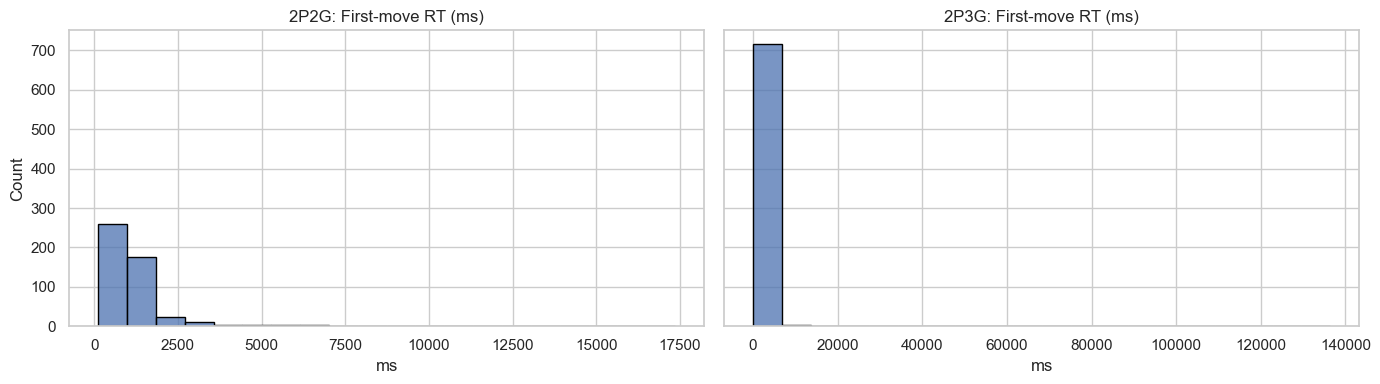

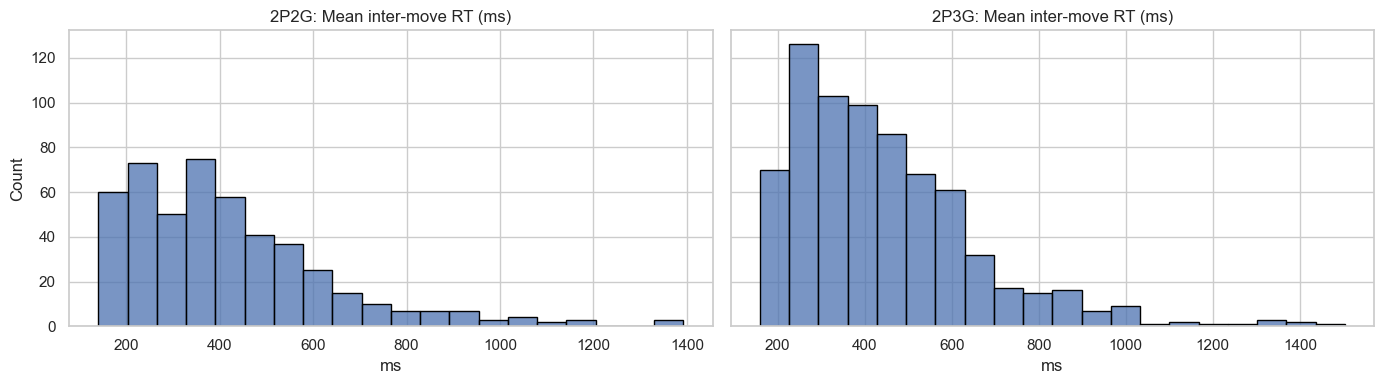

In [3]:
# Hist: first-move RT by experiment
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, exp in zip(axes, ['2P2G','2P3G']):
    sub = rt_df[(rt_df['experimentType']==exp) & rt_df['first_move_rt_ms'].notna()]
    if sub.empty:
        ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes)
        ax.set_axis_off()
        continue
    sns.histplot(sub['first_move_rt_ms'], bins=20, ax=ax, edgecolor='black')
    ax.set_title(f'{exp}: First-move RT (ms)')
    ax.set_xlabel('ms')
axes[0].set_ylabel('Count')
plt.tight_layout()

# Hist: mean inter-move RT by experiment
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, exp in zip(axes, ['2P2G','2P3G']):
    sub = rt_df[(rt_df['experimentType']==exp) & rt_df['mean_inter_move_rt_ms'].notna()]
    if sub.empty:
        ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes)
        ax.set_axis_off()
        continue
    sns.histplot(sub['mean_inter_move_rt_ms'], bins=20, ax=ax, edgecolor='black')
    ax.set_title(f'{exp}: Mean inter-move RT (ms)')
    ax.set_xlabel('ms')
axes[0].set_ylabel('Count')
plt.tight_layout()

## Summary by RL type

Bar plots of mean RTs by experiment and RL agent type (with 95% CI).


/opt/anaconda3/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname G identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/opt/anaconda3/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname G identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/opt/anaconda3/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname G identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified 

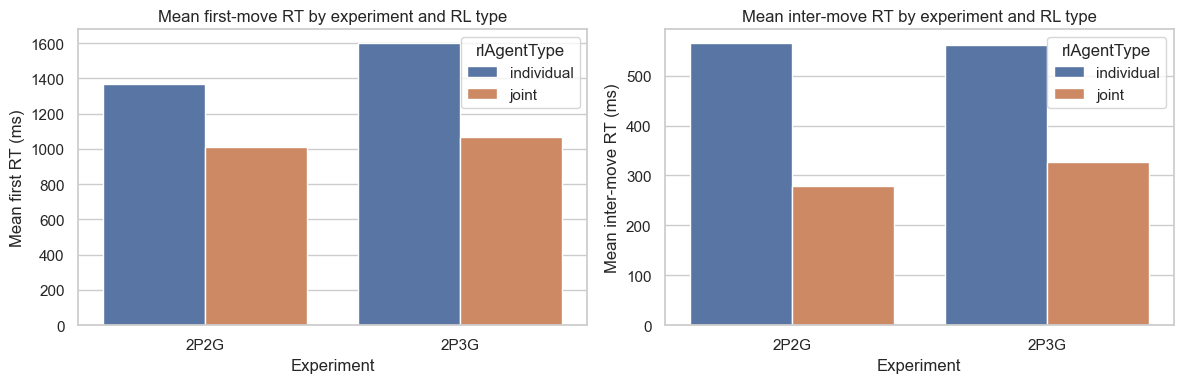

In [4]:
# Aggregate means per experiment x RL type
agg = (rt_df.groupby(['experimentType','rlAgentType'])
             .agg(first_move_rt_ms=('first_move_rt_ms','mean'),
                  mean_inter_move_rt_ms=('mean_inter_move_rt_ms','mean'))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=False)
sns.barplot(data=agg, x='experimentType', y='first_move_rt_ms', hue='rlAgentType', ax=axes[0])
axes[0].set_title('Mean first-move RT by experiment and RL type')
axes[0].set_xlabel('Experiment')
axes[0].set_ylabel('Mean first RT (ms)')

sns.barplot(data=agg, x='experimentType', y='mean_inter_move_rt_ms', hue='rlAgentType', ax=axes[1])
axes[1].set_title('Mean inter-move RT by experiment and RL type')
axes[1].set_xlabel('Experiment')
axes[1].set_ylabel('Mean inter-move RT (ms)')
plt.tight_layout()

## Statistical Summary (RT)

Group-wise table for 2P2G vs 2P3G (by RL type) including:
- n, mean, sd, sem
- 95% CI: mean ± 1.96 × sem
- 1 SD range: mean ± sd

Reported for `first_move_rt_ms` and `mean_inter_move_rt_ms`.


In [7]:
import numpy as np
import pandas as pd

group_keys = ['experimentType','rlAgentType']
vars_to_summarize = ['first_move_rt_ms','mean_inter_move_rt_ms']

def summarize_var(df, col):
    g = (df[df[col].notna()]
         .groupby(group_keys)[col]
         .agg(n='count', mean='mean', sd='std', sem='sem'))
    g['ci_low'] = g['mean'] - 1.96 * g['sem']
    g['ci_high'] = g['mean'] + 1.96 * g['sem']
    g['sd_low'] = g['mean'] - g['sd']
    g['sd_high'] = g['mean'] + g['sd']
    g = g[['n','mean','sd','sem','ci_low','ci_high','sd_low','sd_high']].round(1)
    g.columns = pd.Index([f'{col}__{c}' for c in g.columns])
    return g

summaries = []
for v in vars_to_summarize:
    summaries.append(summarize_var(rt_df, v))

summary = pd.concat(summaries, axis=1).reset_index()
summary


,experimentType,rlAgentType,first_move_rt_ms__n,first_move_rt_ms__mean,first_move_rt_ms__sd,first_move_rt_ms__sem,first_move_rt_ms__ci_low,first_move_rt_ms__ci_high,first_move_rt_ms__sd_low,first_move_rt_ms__sd_high,mean_inter_move_rt_ms__n,mean_inter_move_rt_ms__mean,mean_inter_move_rt_ms__sd,mean_inter_move_rt_ms__sem,mean_inter_move_rt_ms__ci_low,mean_inter_move_rt_ms__ci_high,mean_inter_move_rt_ms__sd_low,mean_inter_move_rt_ms__sd_high
0,2P2G,individual,240,1369.4,1511.3,97.6,1178.2,1560.6,-142.0,2880.7,240,564.3,212.2,13.7,537.5,591.2,352.1,776.5
1,2P2G,joint,240,1010.5,566.3,36.6,938.8,1082.1,444.2,1576.7,240,279.0,94.3,6.1,267.1,291.0,184.7,373.3
2,2P3G,individual,360,1598.3,7242.3,381.7,850.2,2346.5,-5644.0,8840.6,360,561.4,207.6,10.9,539.9,582.8,353.7,769.0
3,2P3G,joint,360,1067.3,3240.2,170.8,732.6,1402.0,-2172.9,4307.5,360,327.2,138.3,7.3,312.9,341.5,188.9,465.4
